In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
project_root = "/Users/denis.carabadjac/Python/ML_projects/house_price_prediction"
sys.path.append(project_root)
from src.utils.visualisation import dc_style

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')
plt.style.use(dc_style)

%load_ext autoreload
%autoreload 2

In [82]:
df = pd.read_csv('../data/processed/apartments_data_20-50.csv')

In [74]:
df.columns


Index(['bathroom', 'rooms', 'apartment_condition', 'total_floors', 'floor',
       'region', 'city', 'sector', 'street', 'area', 'price_per_sqm',
       'floor_ratio', 'has_balcony', 'has_living',
       'building_type_Kомбинированный', 'building_type_Kотельцовый',
       'building_type_Mонолитный', 'building_type_Бетон',
       'building_type_Блочный', 'building_type_Панельный',
       'building_type_Ячеистый Бетон', 'housing_stock_Новострой',
       'author_Банк', 'author_Застройщик', 'author_Частное лицо',
       'parcing_space_Гараж', 'parcing_space_Под навесом',
       'parcing_space_Подземная', 'latitude', 'longitude',
       'distance_to_sector_center'],
      dtype='str')

In [75]:
df = df[df['price_per_sqm'] < 1000000]

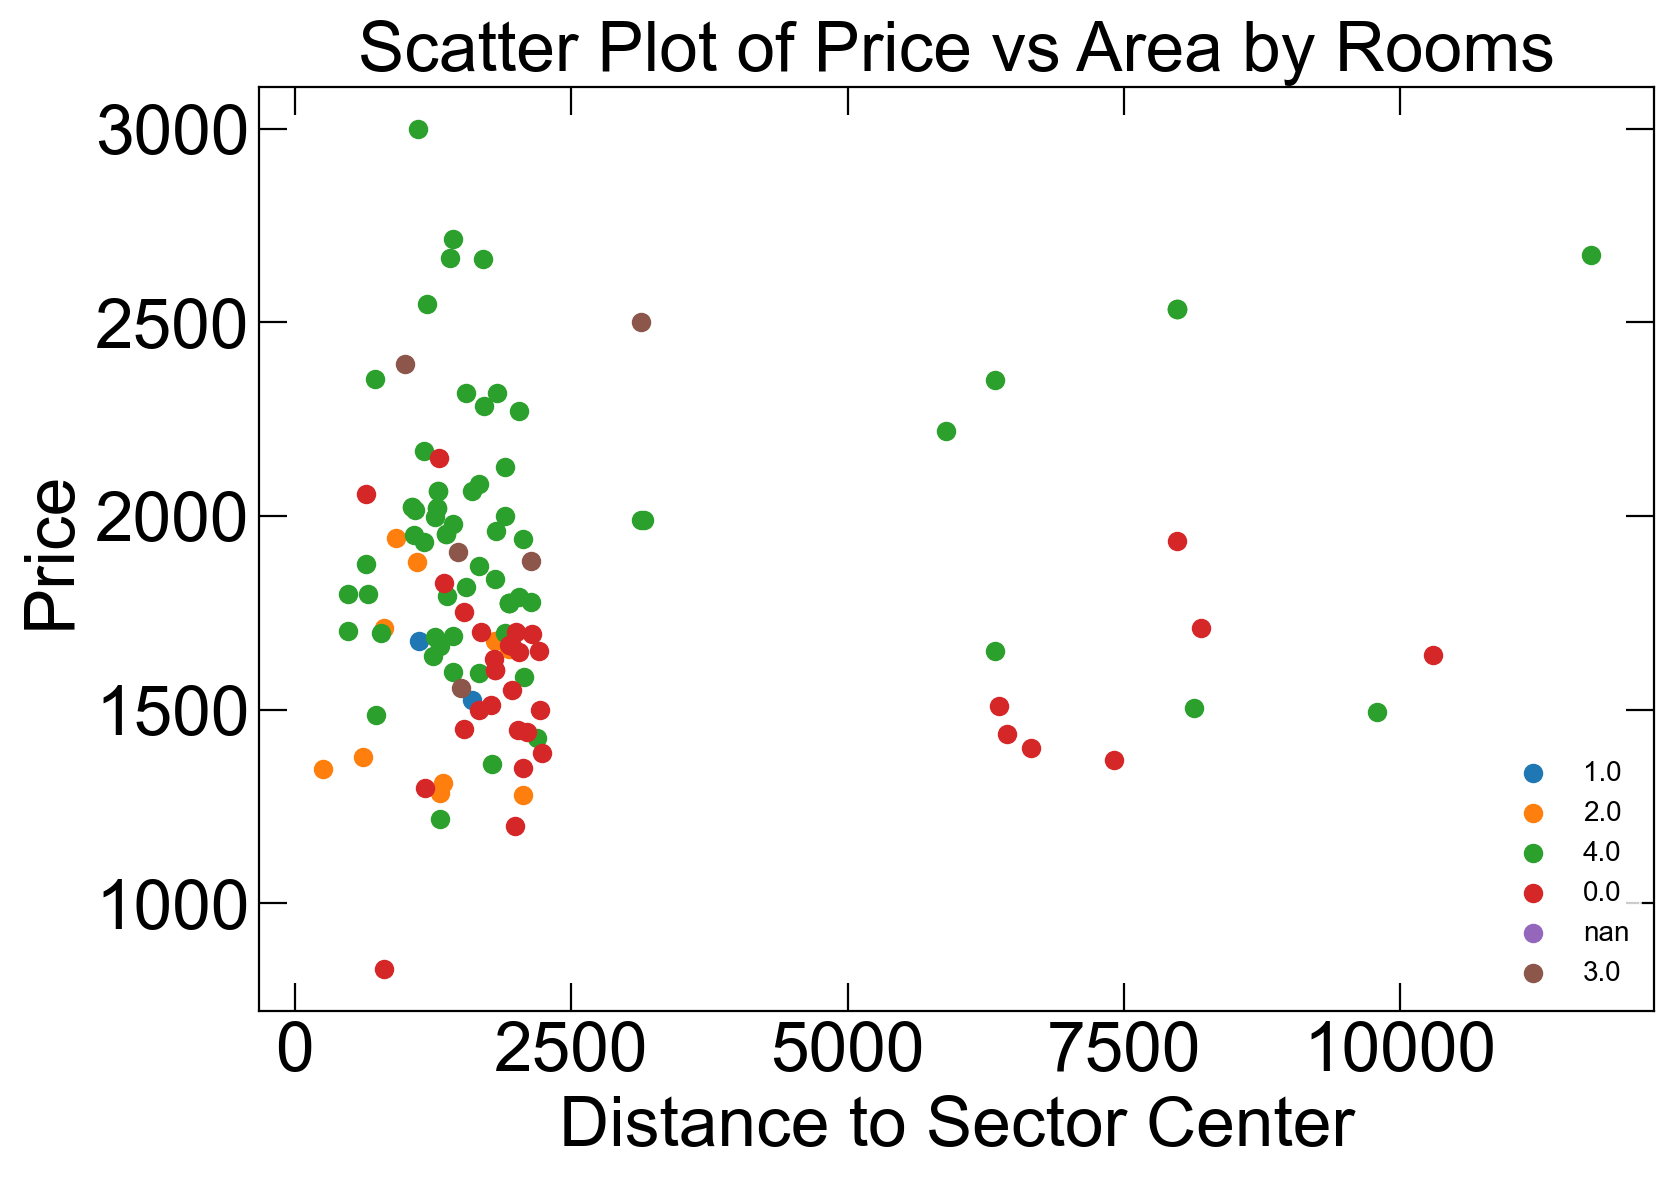

In [81]:
group = 'apartment_condition'

for room in df[group].unique():
    sel_room = df[group] == room
    sel_city = df['city'] == 'Кишинёв'
    sel_sector =  df['sector']== 'Ботаника'
    plt.scatter(df[sel_room & sel_city & sel_sector]['distance_to_sector_center'],
                 df[sel_room & sel_city & sel_sector]['price_per_sqm'], label=f'{room}')
plt.xlabel('Distance to Sector Center')
plt.ylabel('Price')
plt.title('Scatter Plot of Price vs Area by Rooms')
plt.legend(fontsize=10)
plt.show()


In [14]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


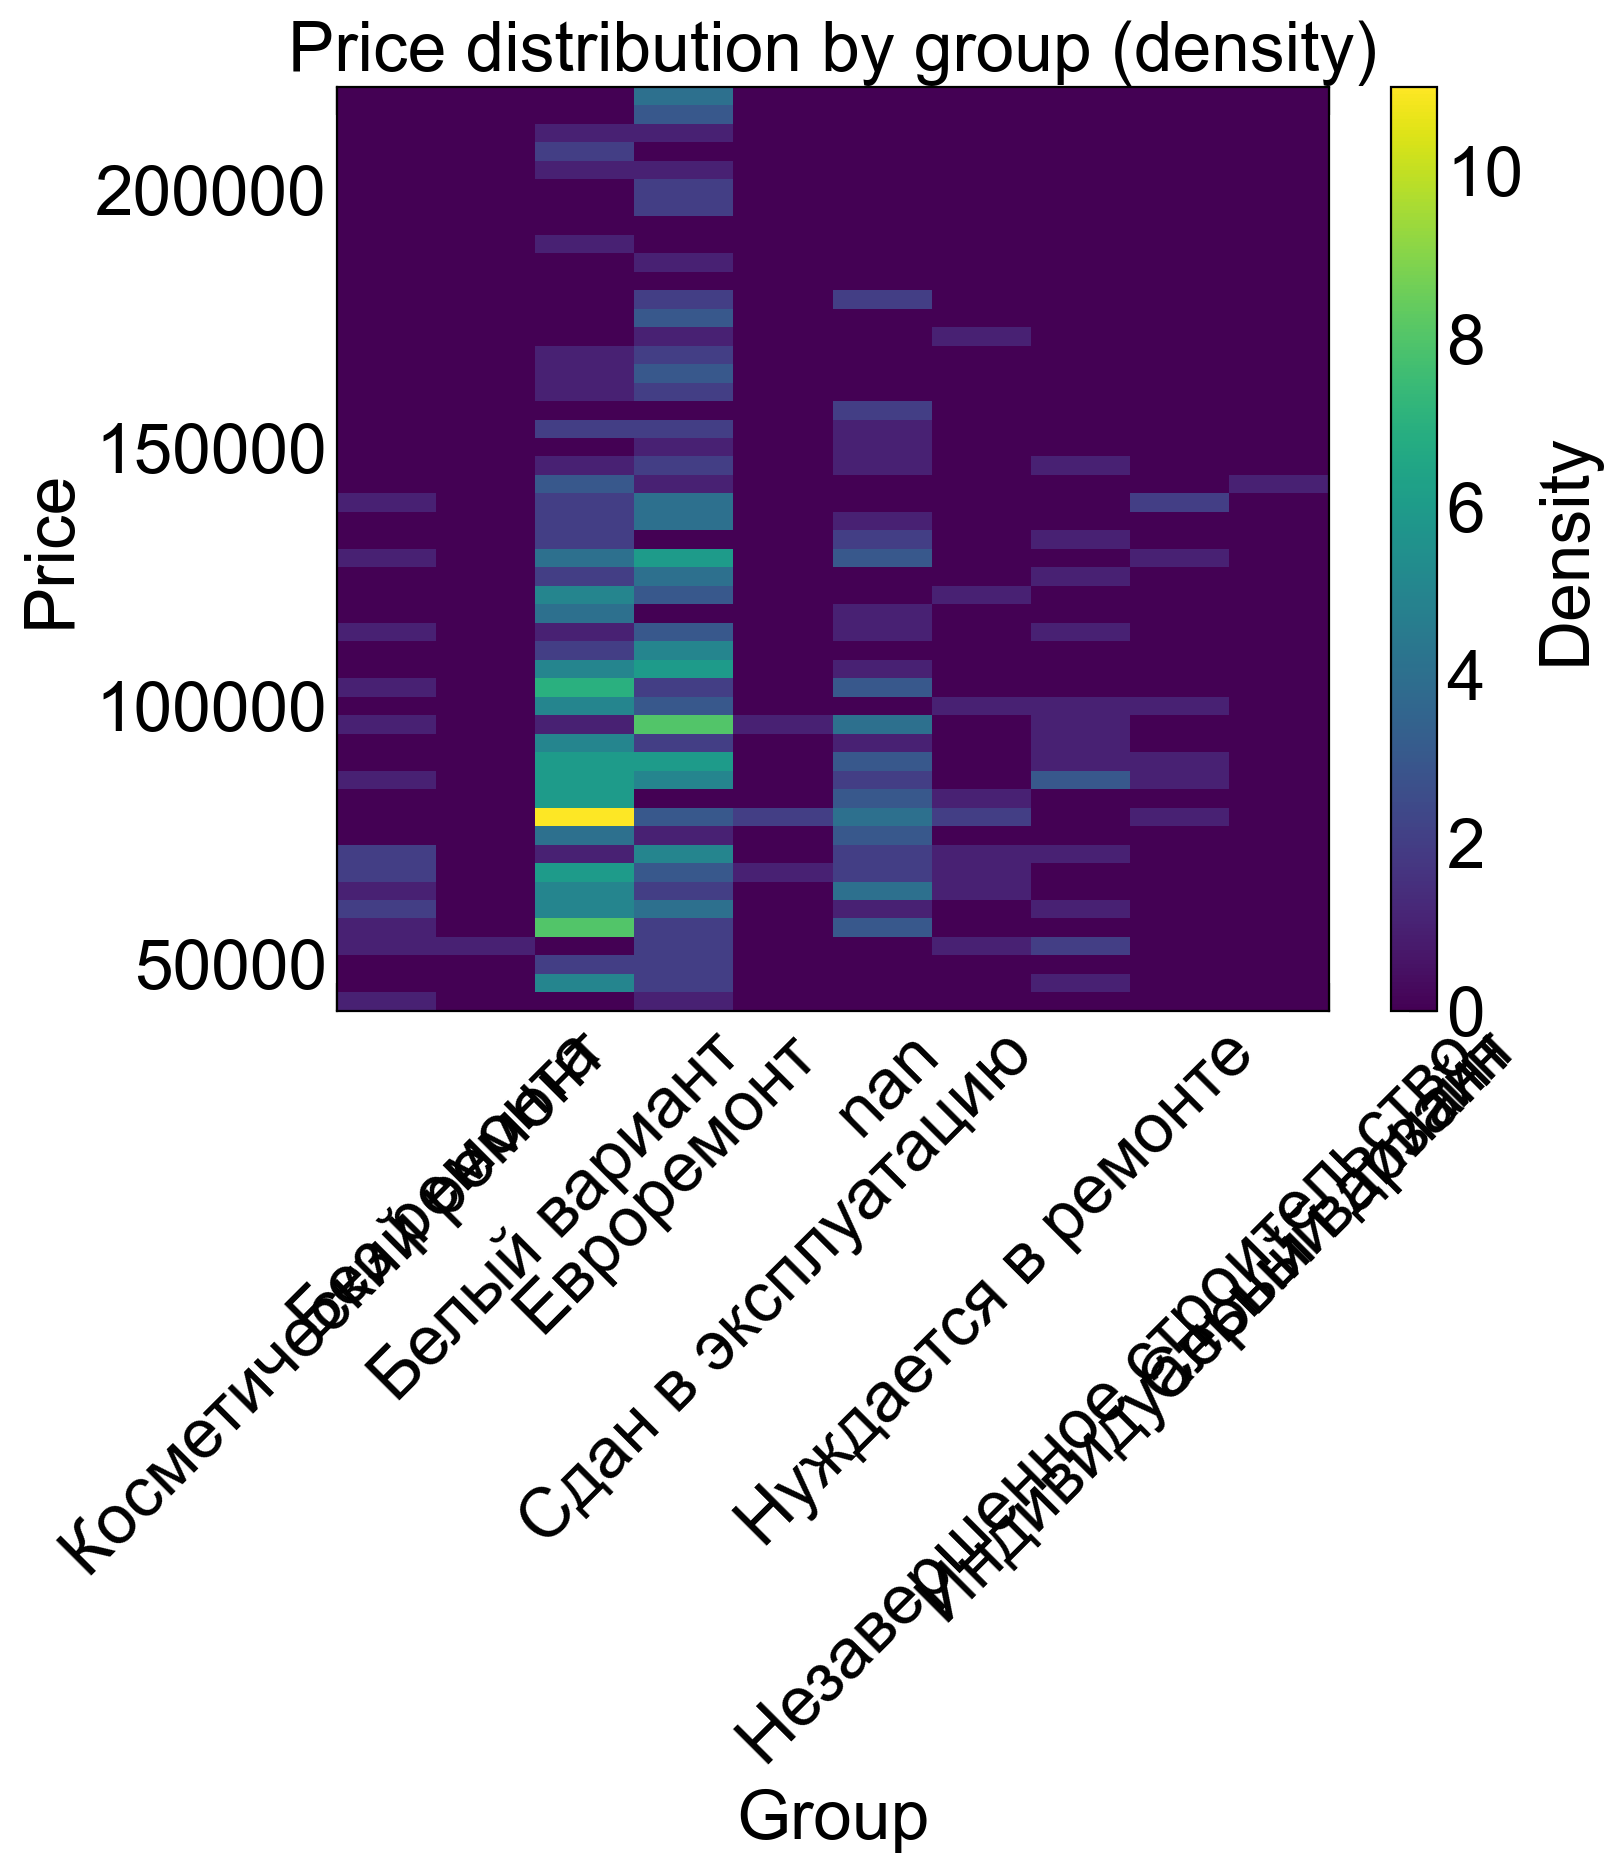

In [18]:
import numpy as np
import matplotlib.pyplot as plt

q_low = df['price'].quantile(0.05)
q_high = df['price'].quantile(0.95)

# фильтруем данные
df_filtered = df[(df['price'] >= q_low) & (df['price'] <= q_high)]

# категории → числа
groups = df_filtered['apartment_condition'].unique()
group_to_x = {g: i for i, g in enumerate(groups)}

x = np.array([group_to_x[g] for g in df_filtered['apartment_condition']])
y = df_filtered['price'].values

plt.figure(figsize=(8, 6))

# 2D histogram (density)
plt.hist2d(x, y, bins=[len(groups), 50])

# подписи оси X
plt.xticks(range(len(groups)), groups, rotation=45)

plt.xlabel("Group")
plt.ylabel("Price")
plt.title("Price distribution by group (density)")

plt.colorbar(label="Density")

plt.show()

In [139]:
from sklearn.model_selection import train_test_split
from src.models.evaluate import evaluate
from src.models.train import train_model
from src.utils.config import load_config
from src.models.registry import get_models
from sklearn.preprocessing import StandardScaler

config_path="../configs/config.yaml"
config = load_config(config_path)
#move to cleaning
df = pd.read_csv('../data/processed/apartments_data_20-50.csv')

bathrooms_mapping = {'0': 0, '1': 1, '2': 2, '3': 3, '4 и более': 4}
df = df.dropna()
df['bathroom'] = df['bathroom'].map(bathrooms_mapping)

df = pd.get_dummies(df, columns=['city', 'sector'], drop_first=True, dtype=int)
df = df[df['price_per_sqm'] < 10000] #remove outliers

X = df.drop(columns=["price_per_sqm", "street", "region", "distance_to_sector_center", "latitude", "longitude"])

scaler = StandardScaler()
X = scaler.fit_transform(X)

y = df["price_per_sqm"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(len(X_train), len(y_train))

models = get_models()
eval_errors = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    trained_model = train_model(model, X_train, y_train)
    y_pred = trained_model.predict(X_test)
    score = evaluate(trained_model, X_test, y_test)
    
    eval_errors[name] = score
    print(score)


401 401
Training linear_regression...
251.6640824731499
Training random_forest...
275.14177953423246
Training gradient_boosting...
259.32877471675624


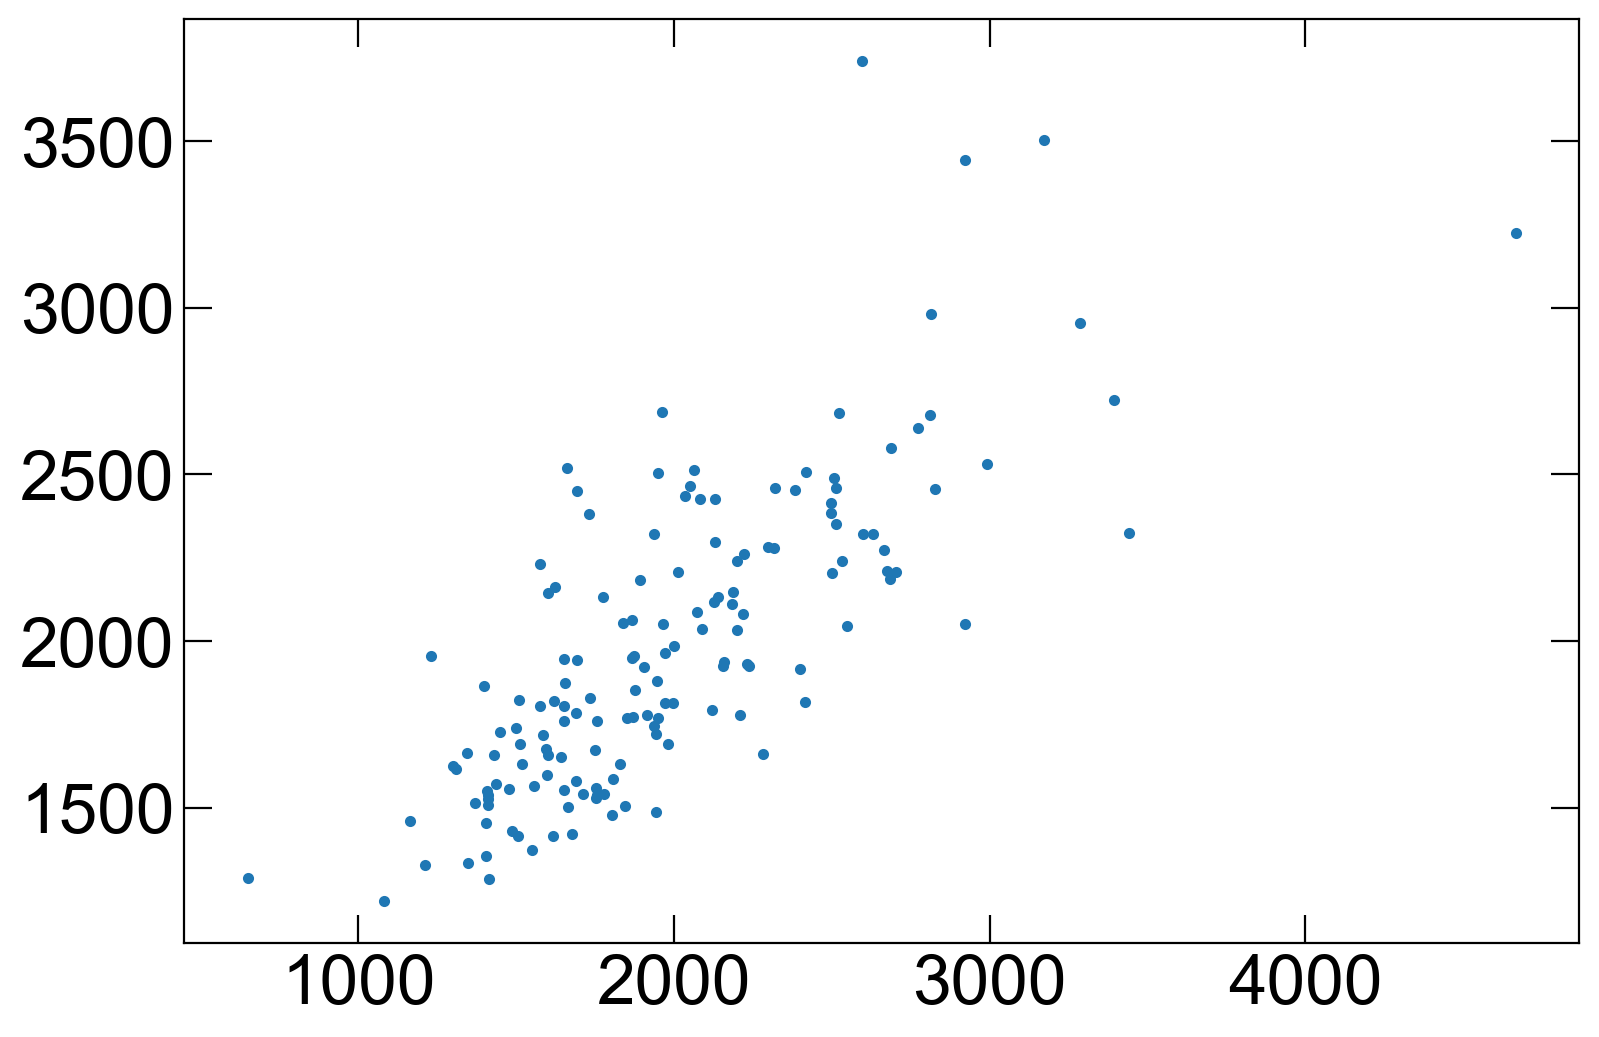

In [123]:
plt.plot(y_test.values, y_pred, marker='.', ls='')



In [104]:
X


array([[-0.69764281, -1.24229911, -0.82779434, ..., -0.32128773,
         1.80969611, -0.40079107],
       [-0.69764281,  1.28666694, -0.27557263, ...,  3.1124749 ,
        -0.55257896, -0.40079107],
       [-0.69764281,  1.28666694,  0.82887079, ..., -0.32128773,
        -0.55257896, -0.40079107],
       ...,
       [-0.69764281,  0.02218391, -1.38001605, ...,  3.1124749 ,
        -0.55257896, -0.40079107],
       [-0.69764281, -1.24229911, -1.38001605, ..., -0.32128773,
        -0.55257896, -0.40079107],
       [-0.69764281,  1.28666694,  0.82887079, ..., -0.32128773,
        -0.55257896, -0.40079107]], shape=(513, 37))